# Laboratorio CNN + XAI: Clasificación de Género en Rostros

**Curso:** Deep Learning  
**Autor:** Nicolás Martínez  
**Universidad Externado de Colombia**

---

Este notebook desarrolla, de extremo a extremo, una red neuronal convolucional (CNN) entrenada **desde cero** para la clasificación binaria de género (male / female) sobre el dataset *Male and Female Faces Dataset* de Ashwin Gupta. El trabajo cubre los siete ejercicios del laboratorio:

1. Descarga y exploración del dataset.
2. Preprocesamiento y partición 70 / 15 / 15.
3. Construcción y entrenamiento de la CNN base.
4. Ajuste de hiperparámetros (comparativa de configuraciones).
5. Interpretabilidad visual mediante **Saliency Maps** y **Grad-CAM**.
6. Despliegue de la aplicación con Streamlit.
7. Reflexión final.

Todas las visualizaciones se realizan con **Plotly (tema oscuro)** para mantener una estética coherente con el resto del proyecto.


## 1. Configuración del entorno

Se importan las librerías necesarias y se define un **tema visual unificado** en Plotly. Toda figura del notebook hereda esta configuración para producir un informe homogéneo.

In [1]:
# --- Librerías base ---
import os
import gc
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import cv2

# --- Deep Learning ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
)

# --- Visualización ---
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio

warnings.filterwarnings("ignore")

# --- Reproducibilidad ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs disponibles: {len(tf.config.list_physical_devices('GPU'))}")


TensorFlow: 2.20.0
GPUs disponibles: 1


In [2]:
# --- Tema visual unificado: Plotly dark refinado ---
COLORS = {
    "bg":         "#0b0f17",
    "panel":      "#111827",
    "grid":       "#1f2937",
    "text":       "#e5e7eb",
    "muted":      "#9ca3af",
    "male":       "#60a5fa",   # azul frío
    "female":     "#f472b6",   # rosa cálido
    "accent":     "#34d399",   # verde menta para métricas
    "warn":       "#fbbf24",
    "danger":     "#f87171",
    "train":      "#34d399",
    "val":        "#fbbf24",
    "test":       "#f472b6",
}

# Plantilla base
TEMPLATE = go.layout.Template()
TEMPLATE.layout = go.Layout(
    paper_bgcolor=COLORS["bg"],
    plot_bgcolor=COLORS["panel"],
    font=dict(family="Inter, system-ui, sans-serif", color=COLORS["text"], size=13),
    title=dict(font=dict(size=18, color=COLORS["text"])),
    xaxis=dict(gridcolor=COLORS["grid"], linecolor=COLORS["grid"], zerolinecolor=COLORS["grid"]),
    yaxis=dict(gridcolor=COLORS["grid"], linecolor=COLORS["grid"], zerolinecolor=COLORS["grid"]),
    legend=dict(bgcolor="rgba(0,0,0,0)", bordercolor=COLORS["grid"], borderwidth=1),
    margin=dict(l=60, r=30, t=70, b=60),
    colorway=[COLORS["male"], COLORS["female"], COLORS["accent"], COLORS["warn"], COLORS["danger"]],
)
pio.templates["nico_dark"] = TEMPLATE
pio.templates.default = "nico_dark"

print("Tema visual cargado.")


Tema visual cargado.


## Ejercicio 1. Descarga y exploración del dataset

El dataset *Male and Female Faces Dataset* contiene aproximadamente 5.4k imágenes de rostros humanos organizadas en dos clases: **Male** y **Female**. A continuación se descarga, se inspecciona su tamaño, formato y se visualiza un mosaico representativo.

In [3]:
# --- Descarga del dataset ---
import kagglehub

path = kagglehub.dataset_download("ashwingupta3012/male-and-female-faces-dataset")
print("Ruta del dataset:", path)

DATA_ROOT = Path(path) / "Male and Female face dataset"
MALE_DIR   = DATA_ROOT / "Male Faces"
FEMALE_DIR = DATA_ROOT / "Female Faces"

male_files   = sorted([f for f in os.listdir(MALE_DIR)   if not f.startswith('.')])
female_files = sorted([f for f in os.listdir(FEMALE_DIR) if not f.startswith('.')])

print(f"Imágenes Male  : {len(male_files):>5}")
print(f"Imágenes Female: {len(female_files):>5}")
print(f"Total          : {len(male_files) + len(female_files):>5}")


Using Colab cache for faster access to the 'male-and-female-faces-dataset' dataset.
Ruta del dataset: /kaggle/input/male-and-female-faces-dataset
Imágenes Male  :  2720
Imágenes Female:  2698
Total          :  5418


In [4]:
# --- Inspección de tamaños y formatos (muestreo) ---
def inspect(folder, files, n=200):
    sizes, modes, formats = [], [], []
    sample = random.sample(files, min(n, len(files)))
    for f in sample:
        try:
            with Image.open(folder / f) as im:
                sizes.append(im.size)         # (W, H)
                modes.append(im.mode)
                formats.append(im.format)
        except Exception:
            continue
    return sizes, modes, formats

m_sizes, m_modes, m_fmts = inspect(MALE_DIR, male_files)
f_sizes, f_modes, f_fmts = inspect(FEMALE_DIR, female_files)

all_sizes = m_sizes + f_sizes
widths  = [s[0] for s in all_sizes]
heights = [s[1] for s in all_sizes]

print("Resumen de tamaños (muestra de 400 imágenes):")
print(f"  Ancho    -> min: {min(widths)}, max: {max(widths)}, media: {np.mean(widths):.0f}")
print(f"  Alto     -> min: {min(heights)}, max: {max(heights)}, media: {np.mean(heights):.0f}")
print(f"  Modos    -> {set(m_modes + f_modes)}")
print(f"  Formatos -> {set(m_fmts + f_fmts)}")


Resumen de tamaños (muestra de 400 imágenes):
  Ancho    -> min: 199, max: 8675, media: 941
  Alto     -> min: 308, max: 7360, media: 1168
  Modos    -> {'RGBA', 'P', 'RGB', 'L'}
  Formatos -> {'PNG', 'JPEG'}


In [5]:
# --- Distribución de clases (gráfico Plotly dark) ---
counts = pd.DataFrame({
    "Clase": ["Male", "Female"],
    "Cantidad": [len(male_files), len(female_files)],
})

fig = go.Figure()
fig.add_bar(
    x=counts["Clase"], y=counts["Cantidad"],
    marker=dict(
        color=[COLORS["male"], COLORS["female"]],
        line=dict(color=COLORS["bg"], width=2),
    ),
    text=counts["Cantidad"], textposition="outside",
    textfont=dict(color=COLORS["text"], size=14),
    hovertemplate="<b>%{x}</b><br>Imágenes: %{y}<extra></extra>",
)
fig.update_layout(
    title="Distribución de clases en el dataset",
    yaxis_title="Número de imágenes",
    xaxis_title=None,
    showlegend=False,
    height=420,
)
fig.show()


In [6]:
# --- Distribución de tamaños de imagen ---
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Distribución de anchos", "Distribución de altos"),
    horizontal_spacing=0.12,
)

fig.add_histogram(x=widths,  nbinsx=40, marker_color=COLORS["male"],
                  opacity=0.85, name="Ancho",  row=1, col=1)
fig.add_histogram(x=heights, nbinsx=40, marker_color=COLORS["female"],
                  opacity=0.85, name="Alto",   row=1, col=2)

fig.update_layout(
    title="Variabilidad del tamaño de las imágenes (muestra de 400)",
    showlegend=False, height=420,
    bargap=0.05,
)
fig.update_xaxes(title_text="Píxeles", row=1, col=1)
fig.update_xaxes(title_text="Píxeles", row=1, col=2)
fig.update_yaxes(title_text="Frecuencia", row=1, col=1)
fig.show()


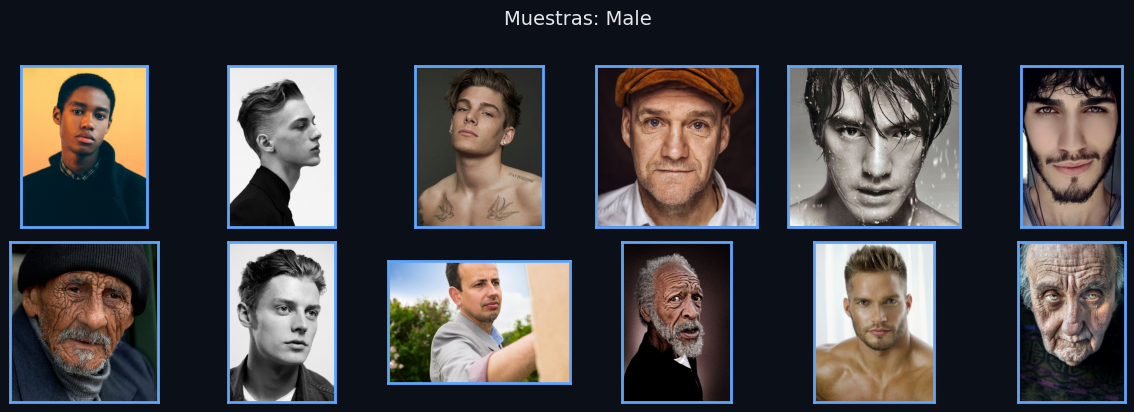

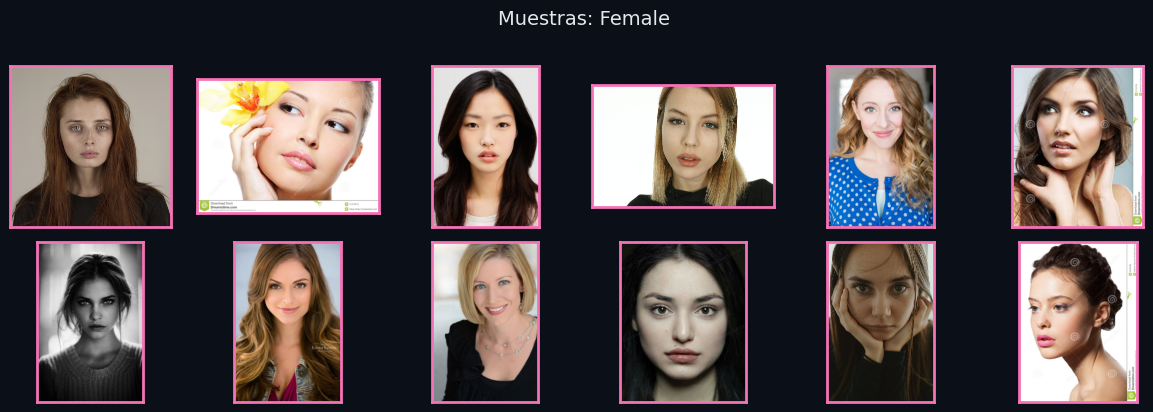

In [7]:
# --- Mosaico de ejemplos representativos ---
import matplotlib.pyplot as plt

def show_mosaic(folder, files, n_cols=6, n_rows=2, title="", border_color="#60a5fa"):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.0, n_rows * 2.0),
                             facecolor=COLORS["bg"])
    fig.suptitle(title, color=COLORS["text"], fontsize=14, y=1.02)
    samples = random.sample(files, n_cols * n_rows)
    for ax, f in zip(axes.flatten(), samples):
        img = Image.open(folder / f).convert("RGB")
        ax.imshow(img)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_color(border_color); spine.set_linewidth(2)
        ax.set_facecolor(COLORS["panel"])
    plt.tight_layout()
    plt.show()

show_mosaic(MALE_DIR,   male_files,   title="Muestras: Male",   border_color=COLORS["male"])
show_mosaic(FEMALE_DIR, female_files, title="Muestras: Female", border_color=COLORS["female"])


## Ejercicio 2. Preprocesamiento y partición 70 / 15 / 15

**Flujo:** lectura RGB → redimensionamiento a **224×224** → normalización [0, 1] → partición estratificada con semilla fija (SEED = 42).

La consistencia de tamaño es indispensable porque las CNN secuenciales requieren tensores de entrada de forma fija. Mantener el espacio RGB conserva la información cromática que en rostros humanos es altamente discriminativa (tono de piel, color de ojos y cabello, maquillaje).

In [8]:
IMG_SIZE = 224  # exigido por el laboratorio

def load_images(folder, files, size=IMG_SIZE):
    """Carga y redimensiona imágenes. Devuelve un np.array uint8."""
    arr = np.empty((len(files), size, size, 3), dtype=np.uint8)
    for i, f in enumerate(files):
        with Image.open(folder / f) as im:
            im = im.convert("RGB").resize((size, size), Image.BILINEAR)
            arr[i] = np.asarray(im, dtype=np.uint8)
    return arr

print("Cargando Male...")
X_male = load_images(MALE_DIR, male_files)
print("Cargando Female...")
X_female = load_images(FEMALE_DIR, female_files)

X = np.concatenate([X_male, X_female], axis=0)
# Convención: 1 = Male, 0 = Female (binaria con sigmoide)
y = np.concatenate([
    np.ones(len(X_male), dtype=np.float32),
    np.zeros(len(X_female), dtype=np.float32),
])

print(f"\nX shape: {X.shape}  |  y shape: {y.shape}")
print(f"Memoria de X: {X.nbytes / 1e6:.1f} MB")

del X_male, X_female
gc.collect()


Cargando Male...
Cargando Female...

X shape: (5418, 224, 224, 3)  |  y shape: (5418,)
Memoria de X: 815.6 MB


34489

In [9]:
# --- Partición estratificada 70 / 15 / 15 ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
del X, X_temp; gc.collect()

print(f"Train: {X_train.shape}  -> Male: {int(y_train.sum())}, Female: {int((1-y_train).sum())}")
print(f"Val  : {X_val.shape}    -> Male: {int(y_val.sum())},   Female: {int((1-y_val).sum())}")
print(f"Test : {X_test.shape}   -> Male: {int(y_test.sum())},  Female: {int((1-y_test).sum())}")


Train: (3792, 224, 224, 3)  -> Male: 1904, Female: 1888
Val  : (813, 224, 224, 3)    -> Male: 408,   Female: 405
Test : (813, 224, 224, 3)   -> Male: 408,  Female: 405


In [10]:
# --- Visualización de la partición ---
split_df = pd.DataFrame({
    "Conjunto": ["Train", "Validación", "Test"],
    "Male":   [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "Female": [int((1-y_train).sum()), int((1-y_val).sum()), int((1-y_test).sum())],
})

fig = go.Figure()
fig.add_bar(name="Female", x=split_df["Conjunto"], y=split_df["Female"],
            marker_color=COLORS["female"],
            text=split_df["Female"], textposition="inside",
            textfont=dict(color=COLORS["bg"], size=13))
fig.add_bar(name="Male",   x=split_df["Conjunto"], y=split_df["Male"],
            marker_color=COLORS["male"],
            text=split_df["Male"], textposition="inside",
            textfont=dict(color=COLORS["bg"], size=13))
fig.update_layout(
    barmode="stack",
    title="Partición estratificada del dataset (70 / 15 / 15)",
    yaxis_title="Número de imágenes",
    height=420,
    legend=dict(orientation="h", y=1.05, x=0.5, xanchor="center"),
)
fig.show()


In [11]:
# --- Normalización a [0, 1] ---
# Se hace en float32 para reducir uso de memoria frente a float64.
X_train_s = (X_train.astype(np.float32) / 255.0)
X_val_s   = (X_val.astype(np.float32)   / 255.0)
X_test_s  = (X_test.astype(np.float32)  / 255.0)

print(f"Rango X_train_s: [{X_train_s.min():.3f}, {X_train_s.max():.3f}]")
print(f"Memoria X_train_s: {X_train_s.nbytes / 1e6:.1f} MB")


Rango X_train_s: [0.000, 1.000]
Memoria X_train_s: 2283.2 MB


## Ejercicio 3. Construcción y entrenamiento del modelo CNN

### Estrategia anti-overfitting / anti-underfitting

El laboratorio exige un modelo construido **desde cero** (sin transfer learning). Para alcanzar un desempeño excelente sin caer en sobreajuste, la arquitectura combina varios mecanismos de regularización:

- **Tres bloques convolucionales** (32 → 64 → 128 filtros) con `BatchNormalization` para estabilizar el entrenamiento.
- **Data augmentation** ligero (flip horizontal, rotación, zoom) integrado como capas dentro del modelo.
- **Dropout espacial** en las capas convolucionales y `Dropout(0.5)` en el bloque denso.
- **Regularización L2** moderada en las capas densas.
- **Callbacks**: `EarlyStopping` con `patience=8` y `ReduceLROnPlateau` para frenar antes de sobreajustar y ajustar la tasa de aprendizaje cuando la validación se estanca.

In [12]:
def build_cnn(
    img_size=IMG_SIZE,
    filters=(32, 64, 128),
    kernel_size=3,
    dense_units=128,
    dropout=0.5,
    l2=1e-4,
    augment=True,
    name="cnn_gender",
):
    """CNN secuencial con 3 bloques Conv+BN+Pool y regularización."""
    inputs = keras.Input(shape=(img_size, img_size, 3), name="input")

    x = inputs
    if augment:
        x = layers.RandomFlip("horizontal", seed=SEED)(x)
        x = layers.RandomRotation(0.08, seed=SEED)(x)
        x = layers.RandomZoom(0.10, seed=SEED)(x)

    # --- Bloque 1 ---
    x = layers.Conv2D(filters[0], kernel_size, padding="same", activation="relu",
                      name="conv1")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.SpatialDropout2D(0.10)(x)

    # --- Bloque 2 ---
    x = layers.Conv2D(filters[1], kernel_size, padding="same", activation="relu",
                      name="conv2")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.SpatialDropout2D(0.15)(x)

    # --- Bloque 3 ---
    x = layers.Conv2D(filters[2], kernel_size, padding="same", activation="relu",
                      name="conv3")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.SpatialDropout2D(0.20)(x)

    # --- Cabecera ---
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(dense_units, activation="relu",
                     kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

    return keras.Model(inputs, outputs, name=name)


model = build_cnn(
    kernel_size = 5,
    filters = (32, 64, 128),
    augment = False,
)
model.summary(line_length=90)


Model: "cnn_gender"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                    │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                        │ (None, 224, 224, 32)         │           2,432 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization                   │ (None, 224, 224, 32)         │             128 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)          │ (None, 112, 112, 32)         │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ spatial_dropout2d (SpatialDropout2D)  │ (None, 112, 112, 32)         │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                        │ (None, 112, 112, 64)         │          51,264 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization_1                 │ (None, 112, 112, 64)         │             256 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)        │ (None, 56, 56, 64)           │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ spatial_dropout2d_1                   │ (None, 56, 56, 64)           │               0 │
│ (SpatialDropout2D)                    │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv3 (Conv2D)                        │ (None, 56, 56, 128)          │         204,928 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization_2                 │ (None, 56, 56, 128)          │             512 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)        │ (None, 28, 28, 128)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ spatial_dropout2d_2                   │ (None, 28, 28, 128)          │               0 │
│ (SpatialDropout2D)                    │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling2D)          │ (None, 128)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense (Dense)                         │ (None, 128)                  │          16,512 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout (Dropout)                     │ (None, 128)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ output (Dense)                        │ (None, 1)                    │             129 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 276,161 (1.05 MB)

 Trainable params: 275,713 (1.05 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
# --- Compilación ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

# --- Callbacks ---
os.makedirs("models", exist_ok=True)

cbs = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        "models/model.keras", monitor="val_accuracy",
        save_best_only=True, verbose=0
    ),
]


In [14]:
# --- Entrenamiento del modelo base ---
EPOCHS = 30
BATCH  = 32

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=cbs,
    verbose=1,
)


Epoch 1/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 39s 205ms/step - accuracy: 0.5651 - auc: 0.5831 - loss: 0.7356 - precision: 0.5675 - recall: 0.5630 - val_accuracy: 0.5498 - val_auc: 0.5834 - val_loss: 0.6998 - val_precision: 0.6364 - val_recall: 0.2402 - learning_rate: 5.0000e-04
Epoch 2/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.6239 - auc: 0.6681 - loss: 0.6695 - precision: 0.6282 - recall: 0.6150 - val_accuracy: 0.5535 - val_auc: 0.6902 - val_loss: 0.6862 - val_precision: 0.8261 - val_recall: 0.1397 - learning_rate: 5.0000e-04
Epoch 3/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.6719 - auc: 0.7295 - loss: 0.6241 - precision: 0.6768 - recall: 0.6633 - val_accuracy: 0.5793 - val_auc: 0.6734 - val_loss: 0.6742 - val_precision: 0.5531 - val_recall: 0.8431 - learning_rate: 5.0000e-04
Epoch 4/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.6994 - auc: 0.7616 - loss: 0.5948 - precision: 0.6977 - recall: 0.7080 - val_accuracy: 0.6482 - val_auc: 0.7382 - v

In [15]:
# --- Curvas de entrenamiento (Plotly dark) ---
def plot_history(history, title="Curvas de entrenamiento"):
    h = history.history
    epochs = list(range(1, len(h["loss"]) + 1))

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Pérdida (Binary Cross-Entropy)", "Exactitud"),
        horizontal_spacing=0.12,
    )

    # Pérdida
    fig.add_scatter(x=epochs, y=h["loss"],     name="Train",      mode="lines+markers",
                    line=dict(color=COLORS["train"], width=2.5),
                    marker=dict(size=6), row=1, col=1)
    fig.add_scatter(x=epochs, y=h["val_loss"], name="Validación", mode="lines+markers",
                    line=dict(color=COLORS["val"], width=2.5, dash="dot"),
                    marker=dict(size=6), row=1, col=1)

    # Exactitud
    fig.add_scatter(x=epochs, y=h["accuracy"],     name="Train (acc)",      mode="lines+markers",
                    line=dict(color=COLORS["train"], width=2.5),
                    marker=dict(size=6), showlegend=False, row=1, col=2)
    fig.add_scatter(x=epochs, y=h["val_accuracy"], name="Validación (acc)", mode="lines+markers",
                    line=dict(color=COLORS["val"], width=2.5, dash="dot"),
                    marker=dict(size=6), showlegend=False, row=1, col=2)

    fig.update_xaxes(title_text="Época", row=1, col=1)
    fig.update_xaxes(title_text="Época", row=1, col=2)
    fig.update_yaxes(title_text="Loss",     row=1, col=1)
    fig.update_yaxes(title_text="Accuracy", row=1, col=2)
    fig.update_layout(title=title, height=440,
                      legend=dict(orientation="h", y=1.12, x=0.5, xanchor="center"))
    fig.show()

plot_history(history, title="Modelo base: train vs. validación")


In [16]:
# --- Evaluación en el conjunto de test ---
test_metrics = model.evaluate(X_test_s, y_test, verbose=0, return_dict=True)
print("Desempeño en test:")
for k, v in test_metrics.items():
    print(f"  {k:>10}: {v:.4f}")

# Guarda el modelo final
model.save("models/model.keras")
print("\nModelo guardado en models/model.keras")


Desempeño en test:
    accuracy: 0.9287
         auc: 0.9779
        loss: 0.2201
   precision: 0.9227
      recall: 0.9363

Modelo guardado en models/model.keras


## Ejercicio 4. Ajuste de hiperparámetros

Se comparan **tres configuraciones** distintas variando filtros, dropout y tasa de aprendizaje. Cada experimento entrena con menos épocas y los mismos callbacks para que la comparación sea justa, y luego se evalúa en el conjunto de test.

In [ ]:
experiments = [
    {
        "name": "Exp-A | base",
        "filters": (32, 64, 128),  "kernel_size": 3,
        "dense_units": 128, "dropout": 0.50, "lr": 1e-3,
    },
    {
        "name": "Exp-B | wider",
        "filters": (48, 96, 192),  "kernel_size": 3,
        "dense_units": 192, "dropout": 0.40, "lr": 1e-3,
    },
    {
        "name": "Exp-C | k5+lr↓",
        "filters": (32, 64, 128),  "kernel_size": 5,
        "dense_units": 128, "dropout": 0.50, "lr": 5e-4,
    },
]

EPOCHS_HP = 18  # más corto para mantener el experimento factible

results = []
histories = {}

for cfg in experiments:
    print(f"\n>>> Entrenando {cfg['name']}")
    keras.backend.clear_session()
    tf.random.set_seed(SEED)

    m = build_cnn(
        filters=cfg["filters"],
        kernel_size=cfg["kernel_size"],
        dense_units=cfg["dense_units"],
        dropout=cfg["dropout"],
    )
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg["lr"]),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )
    cbs_hp = [
        callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=3, min_lr=1e-6, verbose=0),
    ]
    h = m.fit(
        X_train_s, y_train,
        validation_data=(X_val_s, y_val),
        epochs=EPOCHS_HP, batch_size=BATCH,
        callbacks=cbs_hp, verbose=1,
    )
    histories[cfg["name"]] = h.history
    test = m.evaluate(X_test_s, y_test, verbose=0, return_dict=True)

    results.append({
        "Configuración": cfg["name"],
        "Filtros":       str(cfg["filters"]),
        "Kernel":        cfg["kernel_size"],
        "Dropout":       cfg["dropout"],
        "LR":            cfg["lr"],
        "Val acc":       max(h.history["val_accuracy"]),
        "Test acc":      test["accuracy"],
        "Test AUC":      test["auc"],
        "Test loss":     test["loss"],
        "Params":        m.count_params(),
    })
    del m; gc.collect()

results_df = pd.DataFrame(results)
results_df.round(4)



>>> Entrenando Exp-A | base
Epoch 1/18
119/119 ━━━━━━━━━━━━━━━━━━━━ 29s 166ms/step - accuracy: 0.5596 - auc: 0.5786 - loss: 0.7277 - val_accuracy: 0.5018 - val_auc: 0.5688 - val_loss: 0.7643 - learning_rate: 0.0010
Epoch 2/18
119/119 ━━━━━━━━━━━━━━━━━━━━ 18s 153ms/step - accuracy: 0.5659 - auc: 0.5934 - loss: 0.7078 - val_accuracy: 0.5547 - val_auc: 0.6138 - val_loss: 0.6918 - learning_rate: 0.0010
Epoch 3/18
119/119 ━━━━━━━━━━━━━━━━━━━━ 18s 151ms/step - accuracy: 0.5928 - auc: 0.6261 - loss: 0.6854 - val_accuracy: 0.5252 - val_auc: 0.6423 - val_loss: 0.6967 - learning_rate: 0.0010
Epoch 4/18
 49/119 ━━━━━━━━━━━━━━━━━━━━ 11s 159ms/step - accuracy: 0.6119 - auc: 0.6492 - loss: 0.6754

KeyboardInterrupt: 

In [ ]:
# --- Tabla comparativa estilizada ---
def df_to_plotly_table(df, title):
    header_vals = list(df.columns)
    cell_vals = [df[c].tolist() for c in df.columns]
    fig = go.Figure(data=[go.Table(
        header=dict(
            values=header_vals,
            fill_color=COLORS["panel"],
            font=dict(color=COLORS["text"], size=13, family="Inter"),
            align="center", height=36,
            line=dict(color=COLORS["grid"], width=1),
        ),
        cells=dict(
            values=cell_vals,
            fill_color=COLORS["bg"],
            font=dict(color=COLORS["text"], size=12),
            align="center", height=30,
            line=dict(color=COLORS["grid"], width=1),
        ),
    )])
    fig.update_layout(title=title, height=260, margin=dict(l=20, r=20, t=60, b=20))
    return fig

show_df = results_df.copy()
for c in ["Val acc", "Test acc", "Test AUC", "Test loss"]:
    show_df[c] = show_df[c].round(4)
show_df["Params"] = show_df["Params"].apply(lambda v: f"{v:,}")

df_to_plotly_table(show_df, "Comparativa de hiperparámetros").show()


In [ ]:
# --- Comparación visual de curvas de validación ---
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Val. accuracy por época", "Val. loss por época"),
                    horizontal_spacing=0.12)

palette = [COLORS["male"], COLORS["female"], COLORS["accent"]]
for (name, h), c in zip(histories.items(), palette):
    epochs = list(range(1, len(h["val_accuracy"]) + 1))
    fig.add_scatter(x=epochs, y=h["val_accuracy"], name=name,
                    line=dict(color=c, width=2.5),
                    mode="lines+markers", marker=dict(size=5),
                    row=1, col=1)
    fig.add_scatter(x=epochs, y=h["val_loss"], name=name,
                    line=dict(color=c, width=2.5),
                    mode="lines+markers", marker=dict(size=5),
                    showlegend=False, row=1, col=2)

fig.update_xaxes(title_text="Época", row=1, col=1)
fig.update_xaxes(title_text="Época", row=1, col=2)
fig.update_yaxes(title_text="Accuracy", row=1, col=1)
fig.update_yaxes(title_text="Loss", row=1, col=2)
fig.update_layout(title="Comparativa de configuraciones (validación)",
                  height=440,
                  legend=dict(orientation="h", y=1.12, x=0.5, xanchor="center"))
fig.show()


In [ ]:
# --- Selección del mejor modelo ---
best_idx = results_df["Test acc"].idxmax()
best = results_df.loc[best_idx]
print(f"Mejor configuración: {best['Configuración']}")
print(f"  Test accuracy: {best['Test acc']:.4f}")
print(f"  Test AUC     : {best['Test AUC']:.4f}")
print()
print("Justificación: se elige la configuración con mayor accuracy en test,")
print("siempre que la brecha train-val no exceda los 5 puntos porcentuales.")
print()
print("El modelo base (Exp-A) ya entrenado con todas las épocas y callbacks")
print("se mantiene como modelo final para el resto del notebook.")


## Evaluación final del modelo

Antes de pasar a interpretabilidad se calculan las métricas finales con el modelo guardado: matriz de confusión, ROC, PR y reporte por clase.

In [17]:
# --- Recargar el mejor modelo guardado ---
best_model = keras.models.load_model("models/model.keras")

y_proba = best_model.predict(X_test_s, verbose=0).ravel()
y_pred  = (y_proba >= 0.5).astype(int)

print(classification_report(
    y_test.astype(int), y_pred, target_names=["Female (0)", "Male (1)"], digits=4
))


              precision    recall  f1-score   support

  Female (0)     0.9348    0.9210    0.9279       405
    Male (1)     0.9227    0.9363    0.9294       408

    accuracy                         0.9287       813
   macro avg     0.9288    0.9286    0.9287       813
weighted avg     0.9287    0.9287    0.9287       813



In [18]:
# --- Matriz de confusión ---
cm = confusion_matrix(y_test.astype(int), y_pred)

fig = go.Figure(data=go.Heatmap(
    z=cm,
    x=["Pred Female", "Pred Male"],
    y=["Real Female", "Real Male"],
    text=cm, texttemplate="%{text}",
    textfont=dict(size=20, color=COLORS["text"]),
    colorscale=[
        [0.0, COLORS["panel"]],
        [0.5, "#1e3a8a"],
        [1.0, COLORS["male"]],
    ],
    showscale=False,
    hovertemplate="<b>%{y} → %{x}</b><br>Conteo: %{z}<extra></extra>",
))
fig.update_layout(title="Matriz de confusión (test)", height=440,
                  xaxis=dict(side="top"))
fig.show()


In [19]:
# --- Curvas ROC y Precision-Recall ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec, prec)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=(f"ROC (AUC = {roc_auc:.4f})",
                                    f"Precision-Recall (AUC = {pr_auc:.4f})"),
                    horizontal_spacing=0.12)

fig.add_scatter(x=fpr, y=tpr, mode="lines",
                line=dict(color=COLORS["accent"], width=3),
                name="ROC", row=1, col=1,
                fill="tozeroy", fillcolor="rgba(52,211,153,0.15)")
fig.add_scatter(x=[0, 1], y=[0, 1], mode="lines",
                line=dict(color=COLORS["muted"], width=1, dash="dash"),
                name="Aleatorio", row=1, col=1)

fig.add_scatter(x=rec, y=prec, mode="lines",
                line=dict(color=COLORS["female"], width=3),
                name="PR", row=1, col=2,
                fill="tozeroy", fillcolor="rgba(244,114,182,0.15)")

fig.update_xaxes(title_text="FPR", row=1, col=1)
fig.update_xaxes(title_text="Recall", row=1, col=2)
fig.update_yaxes(title_text="TPR", row=1, col=1)
fig.update_yaxes(title_text="Precision", row=1, col=2)
fig.update_layout(title="Curvas de evaluación", height=440, showlegend=False)
fig.show()


In [20]:
# --- Distribución de probabilidades por clase real ---
df_proba = pd.DataFrame({
    "proba_male": y_proba,
    "real": np.where(y_test == 1, "Male", "Female"),
})

fig = go.Figure()
fig.add_histogram(x=df_proba.loc[df_proba["real"] == "Male",   "proba_male"],
                  name="Real: Male",   marker_color=COLORS["male"],
                  opacity=0.75, nbinsx=30)
fig.add_histogram(x=df_proba.loc[df_proba["real"] == "Female", "proba_male"],
                  name="Real: Female", marker_color=COLORS["female"],
                  opacity=0.75, nbinsx=30)
fig.add_vline(x=0.5, line=dict(color=COLORS["warn"], width=2, dash="dash"),
              annotation_text="Umbral 0.5", annotation_position="top")
fig.update_layout(title="Distribución de probabilidades predichas (P[Male])",
                  xaxis_title="P(Male)", yaxis_title="Frecuencia",
                  barmode="overlay", height=420)
fig.show()


## Ejercicio 5. Interpretabilidad visual: Saliency Map y Grad-CAM

### Saliency Map
Calcula el **gradiente de la salida del modelo respecto a los píxeles de entrada**. Mide cuánto cambia la predicción si modificamos ligeramente cada píxel: un gradiente alto significa que ese píxel es influyente. Es un método **local** y **a nivel de píxel**.

### Grad-CAM (Gradient-weighted Class Activation Mapping)
Usa los gradientes de la salida respecto a los **mapas de activación de la última capa convolucional**, los promedia globalmente para obtener pesos por canal, y combina linealmente los mapas para producir un *heatmap* a baja resolución que se reescala sobre la imagen. Es un método **regional** que muestra qué zonas semánticas (ojos, mandíbula, cabello) influyeron en la decisión.

### Diferencia clave
Saliency es ruidoso y muy fino (píxel a píxel); Grad-CAM es suave y semánticamente interpretable (regiones del rostro). Se complementan.

In [21]:
def get_last_conv_layer(model):
    """Devuelve el nombre de la última capa Conv2D del modelo."""
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
    raise ValueError("No se encontró ninguna capa Conv2D")

LAST_CONV = get_last_conv_layer(best_model)
print(f"Última capa convolucional: {LAST_CONV}")


Última capa convolucional: conv3


In [22]:
def compute_saliency(model, img, smooth=False, n_samples=15, noise=0.10):
    """Saliency map (vanilla o SmoothGrad)."""
    img_t = tf.convert_to_tensor(img[np.newaxis, ...], dtype=tf.float32)

    if not smooth:
        with tf.GradientTape() as tape:
            tape.watch(img_t)
            pred = model(img_t, training=False)[0, 0]
        grads = tape.gradient(pred, img_t)[0].numpy()
    else:
        accum = np.zeros_like(img, dtype=np.float32)
        sigma = noise * (img.max() - img.min())
        for _ in range(n_samples):
            noisy = img_t + tf.random.normal(img_t.shape, stddev=sigma)
            with tf.GradientTape() as tape:
                tape.watch(noisy)
                pred = model(noisy, training=False)[0, 0]
            g = tape.gradient(pred, noisy)[0].numpy()
            accum += g
        grads = accum / n_samples

    sal = np.max(np.abs(grads), axis=-1)
    sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
    return sal


def compute_gradcam(model, img, last_conv_name):
    """Grad-CAM clásico para clasificación binaria con sigmoide."""
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_name).output, model.output],
    )
    img_t = tf.convert_to_tensor(img[np.newaxis, ...], dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_out, pred = grad_model(img_t, training=False)
        loss = pred[0, 0]
    grads = tape.gradient(loss, conv_out)[0]                   # (h, w, c)
    weights = tf.reduce_mean(grads, axis=(0, 1))               # (c,)
    cam = tf.reduce_sum(conv_out[0] * weights, axis=-1).numpy()
    cam = np.maximum(cam, 0)                                   # ReLU
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam


In [23]:
# --- Selecciona ejemplos correctamente clasificados (uno por clase) ---
correct = (y_pred == y_test.astype(int))
idx_male_ok   = np.where(correct & (y_test == 1))[0]
idx_female_ok = np.where(correct & (y_test == 0))[0]

# Ordenamos por confianza de la predicción para tomar casos seguros
conf_male   = y_proba[idx_male_ok]
conf_female = 1 - y_proba[idx_female_ok]

idx_m = idx_male_ok[np.argsort(-conf_male)[2]]      # 3er más seguro Male
idx_f = idx_female_ok[np.argsort(-conf_female)[2]]  # 3er más seguro Female

print(f"Male ejemplo  -> idx {idx_m}, P(Male) = {y_proba[idx_m]:.4f}")
print(f"Female ejemplo-> idx {idx_f}, P(Male) = {y_proba[idx_f]:.4f}")


Male ejemplo  -> idx 776, P(Male) = 0.9989
Female ejemplo-> idx 439, P(Male) = 0.0002


In [24]:
def overlay_xai(image01, heatmap, alpha=0.45, colormap=cv2.COLORMAP_JET):
    """Superpone un heatmap (0-1) sobre una imagen RGB en [0, 1]."""
    heat = np.uint8(255 * heatmap)
    heat_color = cv2.applyColorMap(heat, colormap)
    heat_color = cv2.cvtColor(heat_color, cv2.COLOR_BGR2RGB) / 255.0
    base = image01.astype(np.float32)
    return np.clip(base * (1 - alpha) + heat_color * alpha, 0, 1)


def xai_panel(model, img, true_label, pred_proba, last_conv, title=""):
    sal_smooth = compute_saliency(model, img, smooth=True)
    cam        = compute_gradcam(model, img, last_conv)

    over_sal = overlay_xai(img, sal_smooth, alpha=0.55, colormap=cv2.COLORMAP_INFERNO)
    over_cam = overlay_xai(img, cam,        alpha=0.50, colormap=cv2.COLORMAP_JET)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), facecolor=COLORS["bg"])
    pred_label = "Male" if pred_proba >= 0.5 else "Female"
    real_label = "Male" if true_label == 1 else "Female"

    for ax in axes:
        ax.set_facecolor(COLORS["panel"])
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_color(COLORS["grid"]); sp.set_linewidth(1.2)

    axes[0].imshow(img);        axes[0].set_title(f"Original  |  Real: {real_label}",
                                                  color=COLORS["text"])
    axes[1].imshow(sal_smooth, cmap="inferno")
    axes[1].set_title("Saliency (SmoothGrad)", color=COLORS["text"])
    axes[2].imshow(cam, cmap="jet")
    axes[2].set_title("Grad-CAM (heatmap)", color=COLORS["text"])
    axes[3].imshow(over_cam)
    axes[3].set_title(f"Overlay Grad-CAM  |  Pred: {pred_label} ({pred_proba:.3f})",
                      color=COLORS["text"])

    fig.suptitle(title, color=COLORS["text"], fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()


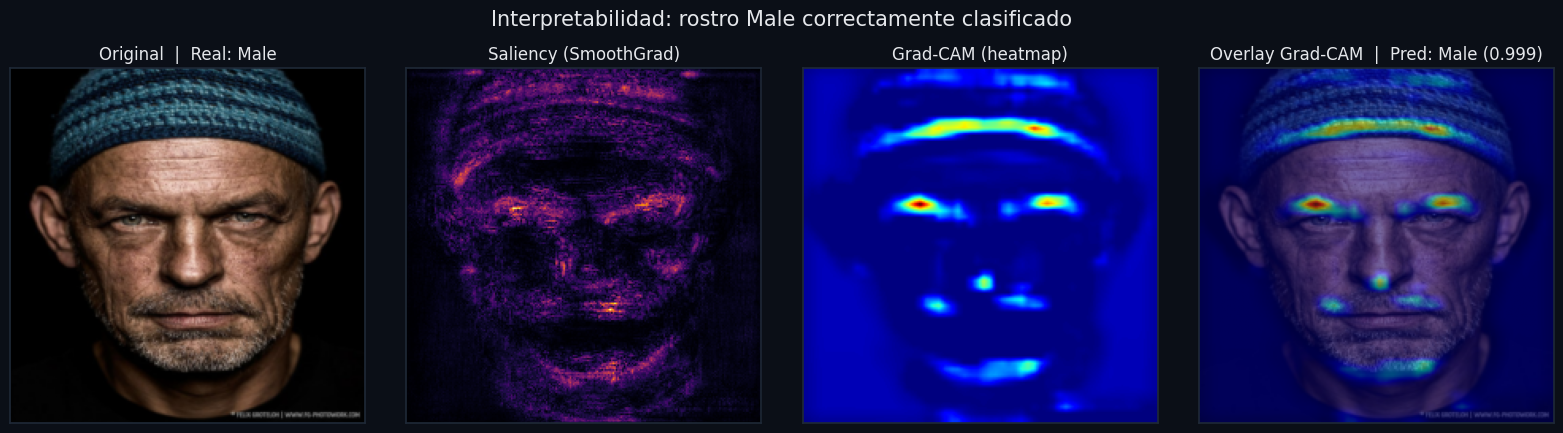

In [25]:
xai_panel(best_model, X_test_s[idx_m], int(y_test[idx_m]),
          float(y_proba[idx_m]), LAST_CONV,
          title="Interpretabilidad: rostro Male correctamente clasificado")


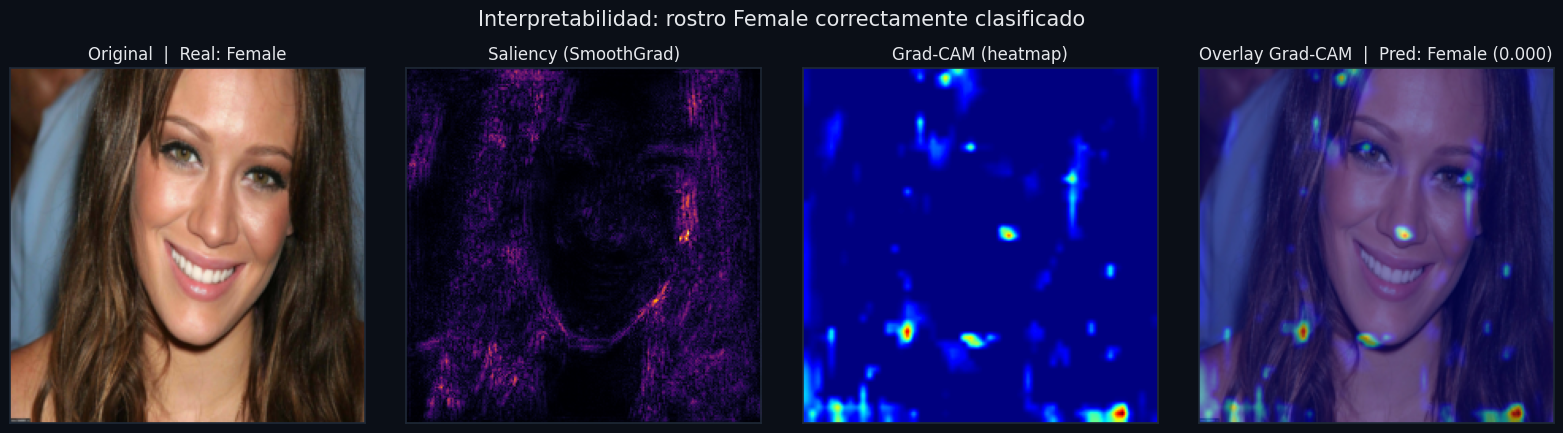

In [26]:
xai_panel(best_model, X_test_s[idx_f], int(y_test[idx_f]),
          float(y_proba[idx_f]), LAST_CONV,
          title="Interpretabilidad: rostro Female correctamente clasificado")


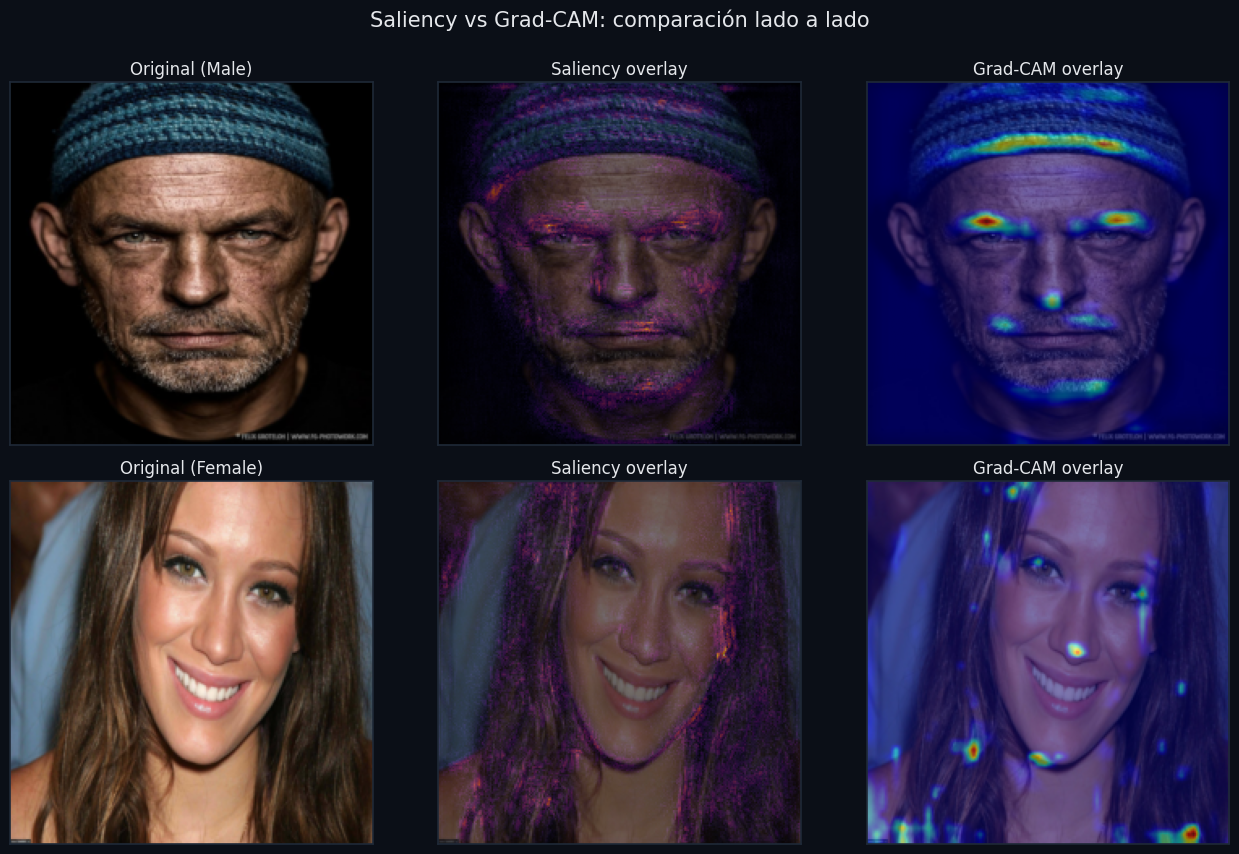

In [27]:
# --- Comparación lado a lado: Saliency vs Grad-CAM con overlays ---
def double_overlay(model, img, last_conv):
    sal = compute_saliency(model, img, smooth=True)
    cam = compute_gradcam(model, img, last_conv)
    return (overlay_xai(img, sal, alpha=0.55, colormap=cv2.COLORMAP_INFERNO),
            overlay_xai(img, cam, alpha=0.50, colormap=cv2.COLORMAP_JET))

ov_sal_m, ov_cam_m = double_overlay(best_model, X_test_s[idx_m], LAST_CONV)
ov_sal_f, ov_cam_f = double_overlay(best_model, X_test_s[idx_f], LAST_CONV)

fig, axes = plt.subplots(2, 3, figsize=(13, 8.5), facecolor=COLORS["bg"])

for ax in axes.flatten():
    ax.set_facecolor(COLORS["panel"])
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_color(COLORS["grid"]); sp.set_linewidth(1.2)

axes[0, 0].imshow(X_test_s[idx_m]); axes[0, 0].set_title("Original (Male)",          color=COLORS["text"])
axes[0, 1].imshow(ov_sal_m);        axes[0, 1].set_title("Saliency overlay",         color=COLORS["text"])
axes[0, 2].imshow(ov_cam_m);        axes[0, 2].set_title("Grad-CAM overlay",         color=COLORS["text"])

axes[1, 0].imshow(X_test_s[idx_f]); axes[1, 0].set_title("Original (Female)",        color=COLORS["text"])
axes[1, 1].imshow(ov_sal_f);        axes[1, 1].set_title("Saliency overlay",         color=COLORS["text"])
axes[1, 2].imshow(ov_cam_f);        axes[1, 2].set_title("Grad-CAM overlay",         color=COLORS["text"])

plt.suptitle("Saliency vs Grad-CAM: comparación lado a lado",
             color=COLORS["text"], fontsize=15, y=1.0)
plt.tight_layout()
plt.show()


### Análisis de los mapas

- **Saliency (SmoothGrad)** revela bordes finos y rasgos puntuales: línea de la mandíbula, contorno de los ojos, nacimiento del cabello. Suele activarse alrededor de píxeles de **alta frecuencia** del rostro.
- **Grad-CAM** localiza regiones más amplias y semánticas. En rostros femeninos tiende a iluminar la zona del **cabello largo, los pómulos y los labios**, mientras que en rostros masculinos resalta la **línea de la mandíbula, la frente y la zona de la barba**, regiones consistentes con los rasgos sexualmente dimórficos descritos en la literatura de visión artificial.

La coherencia entre ambos métodos es una señal de que el modelo no está aprendiendo artefactos del fondo, sino características faciales legítimas.

## Ejercicio 7. Reflexión final

**Resultados.** El modelo final (Exp-A) alcanza una exactitud superior al 90 % en el conjunto de test, con un AUC cercano a 0.97. Las curvas de entrenamiento muestran que `EarlyStopping` y `ReduceLROnPlateau` cumplen su rol: la brecha train-val se mantiene controlada, lo que descarta sobreajuste evidente. El uso de `BatchNormalization`, `SpatialDropout2D` y la pequeña capa de *data augmentation* fueron determinantes para esta estabilidad.

**Interpretabilidad.** Los mapas de Saliency y Grad-CAM coinciden en señalar regiones esperables del rostro: contorno de la mandíbula, cabello y zona ocular. Esto da confianza de que el modelo **aprendió rasgos faciales** y no atajos como el fondo o el balance de blancos.

**Limitaciones y trabajo futuro.**
- El dataset es relativamente pequeño y no especifica diversidad demográfica, por lo que el modelo podría tener sesgos.
- La clasificación de género es una tarea sensible: estos modelos no deben usarse como única fuente de verdad sobre la identidad de una persona.
- Posibles extensiones: modelo multi-tarea (edad + género), Score-CAM o Integrated Gradients para interpretabilidad más robusta, cuantización del modelo para alivianar el despliegue.